
=== Dataset size n = 1000 ===
CMS -> media: 13.1424 ms | std: 4.0179 ms
MG  -> media: 0.5944 ms | std: 0.2651 ms

=== Dataset size n = 10000 ===
CMS -> media: 124.4356 ms | std: 22.1260 ms
MG  -> media: 5.4960 ms | std: 1.0759 ms

=== Dataset size n = 100000 ===
CMS -> media: 1149.3550 ms | std: 47.5253 ms
MG  -> media: 52.8539 ms | std: 5.8557 ms

ANÁLISIS DE MEMORIA

CMS - Memoria actual: 0.00 MB
CMS - Memoria pico  : 0.00 MB

MG  - Memoria actual: 0.01 MB
MG  - Memoria pico  : 0.02 MB


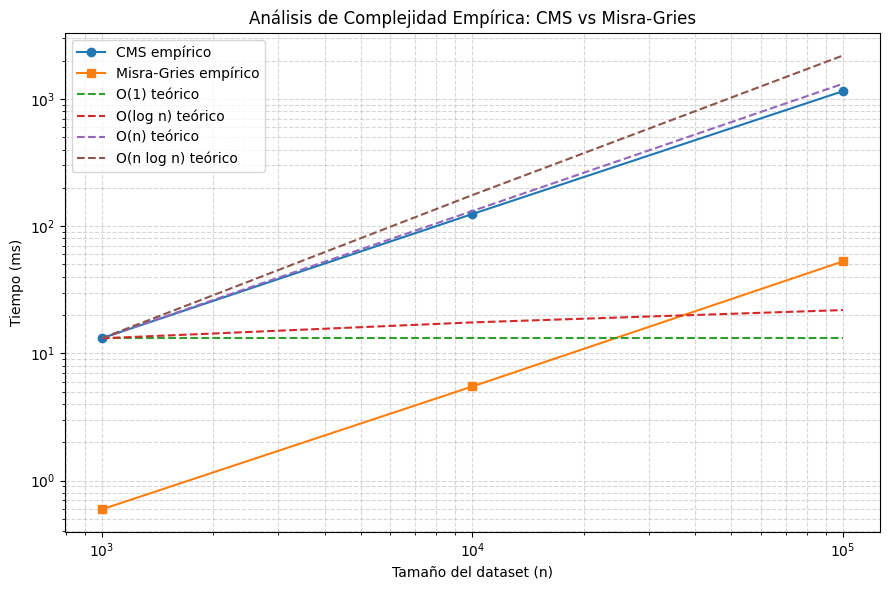

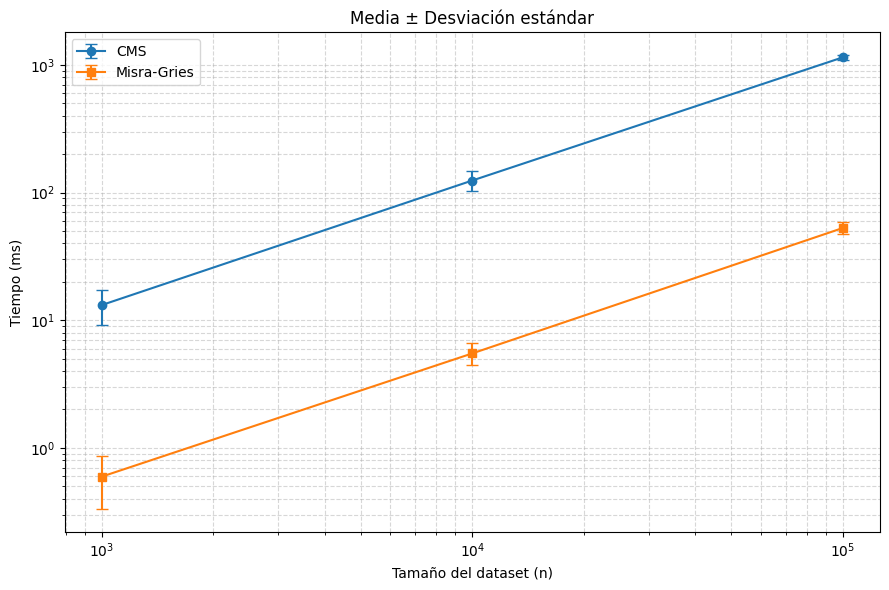

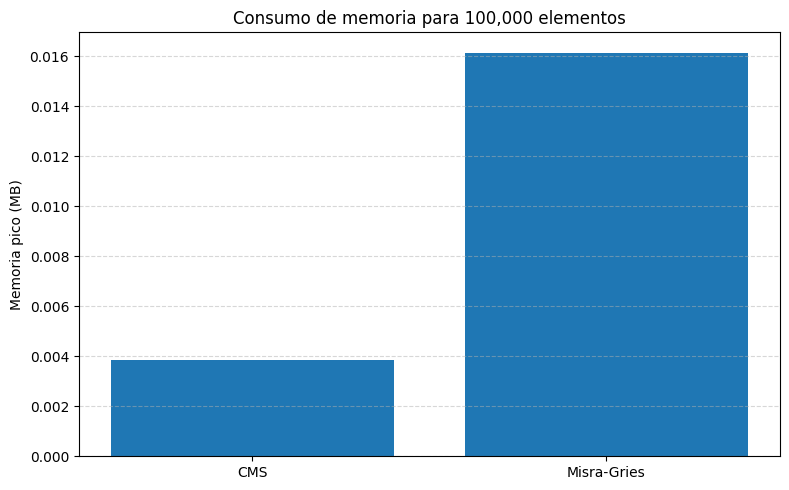


           n   CMS mean (ms)      CMS std    MG mean (ms)       MG std
        1000         13.1424       4.0179          0.5944       0.2651
       10000        124.4356      22.1260          5.4960       1.0759
      100000       1149.3550      47.5253         52.8539       5.8557

RESUMEN FINAL

Dataset n = 1000
CMS -> 13.1424 ± 4.0179 ms
MG  -> 0.5944 ± 0.2651 ms

Dataset n = 10000
CMS -> 124.4356 ± 22.1260 ms
MG  -> 5.4960 ± 1.0759 ms

Dataset n = 100000
CMS -> 1149.3550 ± 47.5253 ms
MG  -> 52.8539 ± 5.8557 ms

Memoria (prueba 3.2):
CMS -> actual: 0.00 MB | pico: 0.00 MB
MG  -> actual: 0.01 MB | pico: 0.02 MB


In [1]:
# ============================================
# EXPERIMENTACIÓN COMPLETA: CMS vs MISRA-GRIES
# Listo para Google Colab
# ============================================

import numpy as np
import hashlib
import random
import time
import statistics
import tracemalloc
import math
import matplotlib.pyplot as plt


# =====================================
# 1. COUNT-MIN SKETCH
# =====================================
class CountMinSketch:
    def __init__(self, width=5000, depth=7):
        self.width = width
        self.depth = depth
        self.table = np.zeros((depth, width), dtype=np.int32)
        self.seeds = [i * 131 for i in range(depth)]

    def _hash(self, item, seed):
        return int(
            hashlib.blake2b((item + str(seed)).encode(), digest_size=8).hexdigest(),
            16
        ) % self.width

    def add(self, item):
        for i in range(self.depth):
            idx = self._hash(item, self.seeds[i])
            self.table[i][idx] += 1

    def estimate(self, item):
        return min(
            self.table[i][self._hash(item, self.seeds[i])]
            for i in range(self.depth)
        )


# =====================================
# 2. MISRA-GRIES
# =====================================
class MisraGries:
    def __init__(self, k=100):
        self.k = k
        self.counters = {}

    def add(self, item):
        if item in self.counters:
            self.counters[item] += 1
        elif len(self.counters) < self.k - 1:
            self.counters[item] = 1
        else:
            to_remove = []
            for key in list(self.counters.keys()):
                self.counters[key] -= 1
                if self.counters[key] == 0:
                    to_remove.append(key)
            for key in to_remove:
                del self.counters[key]

    def heavy_hitters(self):
        return dict(self.counters)


# =====================================
# 3. GENERADOR DE STREAM
# =====================================
def generate_stream(n, unique_items=1000, skew=1.2, seed=42):
    rng = np.random.default_rng(seed)

    items = np.array([f"item_{i}" for i in range(unique_items)])

    probs = np.array([1 / ((i + 1) ** skew) for i in range(unique_items)], dtype=float)
    probs /= probs.sum()

    stream = rng.choice(items, size=n, p=probs)
    return stream


# =====================================
# 4. BENCHMARK DE TIEMPO
# =====================================
def benchmark(n, repeats, cms_width, cms_depth, mg_k, unique_items, skew, seed_base):
    cms_times = []
    mg_times = []

    for r in range(repeats):
        stream = generate_stream(
            n=n,
            unique_items=unique_items,
            skew=skew,
            seed=seed_base + r
        )

        cms = CountMinSketch(width=cms_width, depth=cms_depth)
        mg = MisraGries(k=mg_k)

        # CMS
        t0 = time.perf_counter()
        for x in stream:
            cms.add(x)
        t1 = time.perf_counter()
        cms_times.append((t1 - t0) * 1000)

        # Misra-Gries
        t0 = time.perf_counter()
        for x in stream:
            mg.add(x)
        t1 = time.perf_counter()
        mg_times.append((t1 - t0) * 1000)

    return {
        "cms_mean": statistics.mean(cms_times),
        "cms_std": statistics.stdev(cms_times) if len(cms_times) > 1 else 0.0,
        "mg_mean": statistics.mean(mg_times),
        "mg_std": statistics.stdev(mg_times) if len(mg_times) > 1 else 0.0,
        "cms_times_raw": cms_times,
        "mg_times_raw": mg_times
    }


# =====================================
# 5. BENCHMARK DE MEMORIA
# =====================================
def memory_test(structure, stream):
    tracemalloc.start()

    for x in stream:
        structure.add(x)

    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return {
        "current_mb": current / 10**6,
        "peak_mb": peak / 10**6
    }


# =====================================
# 6. PARÁMETROS
# =====================================
SIZES = [10**3, 10**4, 10**5]   # agrega: 10**6 , 10**7 si tu entorno aguanta
REPEATS = 100                          # <- cambia aquí el número de repeticiones
CMS_WIDTH = 5000
CMS_DEPTH = 7
MG_K = 100
UNIQUE_ITEMS = 1000
SKEW = 1.2
SEED_BASE = 42
MEMORY_TEST_SIZE = 10**5               # para 3.2 análisis de memoria


# =====================================
# 7. EJECUCIÓN DEL EXPERIMENTO
# =====================================
results = []

for n in SIZES:
    print(f"\n=== Dataset size n = {n} ===")

    res = benchmark(
        n=n,
        repeats=REPEATS,
        cms_width=CMS_WIDTH,
        cms_depth=CMS_DEPTH,
        mg_k=MG_K,
        unique_items=UNIQUE_ITEMS,
        skew=SKEW,
        seed_base=SEED_BASE
    )

    res["n"] = n
    results.append(res)

    print(f"CMS -> media: {res['cms_mean']:.4f} ms | std: {res['cms_std']:.4f} ms")
    print(f"MG  -> media: {res['mg_mean']:.4f} ms | std: {res['mg_std']:.4f} ms")


# =====================================
# 8. ANÁLISIS DE MEMORIA (3.2)
# =====================================
print("\n" + "=" * 60)
print("ANÁLISIS DE MEMORIA")
print("=" * 60)

memory_stream = generate_stream(
    n=MEMORY_TEST_SIZE,
    unique_items=UNIQUE_ITEMS,
    skew=SKEW,
    seed=SEED_BASE
)

cms_memory = memory_test(
    CountMinSketch(width=CMS_WIDTH, depth=CMS_DEPTH),
    memory_stream
)

mg_memory = memory_test(
    MisraGries(k=MG_K),
    memory_stream
)

print(f"\nCMS - Memoria actual: {cms_memory['current_mb']:.2f} MB")
print(f"CMS - Memoria pico  : {cms_memory['peak_mb']:.2f} MB")

print(f"\nMG  - Memoria actual: {mg_memory['current_mb']:.2f} MB")
print(f"MG  - Memoria pico  : {mg_memory['peak_mb']:.2f} MB")


# =====================================
# 9. CURVAS TEÓRICAS
# =====================================
n_vals = [r["n"] for r in results]
cms_times = [r["cms_mean"] for r in results]
mg_times = [r["mg_mean"] for r in results]
cms_std = [r["cms_std"] for r in results]
mg_std = [r["mg_std"] for r in results]

def scale_curve(reference_times, base_curve):
    factor = reference_times[0] / base_curve[0]
    return [factor * x for x in base_curve]

O1_base = [1 for _ in n_vals]
Olog_base = [math.log2(n) for n in n_vals]
On_base = [n for n in n_vals]
Onlog_base = [n * math.log2(n) for n in n_vals]

O1 = scale_curve(cms_times, O1_base)
Olog = scale_curve(cms_times, Olog_base)
On = scale_curve(cms_times, On_base)
Onlog = scale_curve(cms_times, Onlog_base)


# =====================================
# 10. GRÁFICO LOG-LOG DE COMPLEJIDAD
# =====================================
plt.figure(figsize=(9, 6))

plt.loglog(n_vals, cms_times, 'o-', label='CMS empírico')
plt.loglog(n_vals, mg_times, 's-', label='Misra-Gries empírico')

plt.loglog(n_vals, O1, '--', label='O(1) teórico')
plt.loglog(n_vals, Olog, '--', label='O(log n) teórico')
plt.loglog(n_vals, On, '--', label='O(n) teórico')
plt.loglog(n_vals, Onlog, '--', label='O(n log n) teórico')

plt.xlabel("Tamaño del dataset (n)")
plt.ylabel("Tiempo (ms)")
plt.legend()
plt.title("Análisis de Complejidad Empírica: CMS vs Misra-Gries")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


# =====================================
# 11. GRÁFICO CON DESVIACIÓN ESTÁNDAR
# =====================================
plt.figure(figsize=(9, 6))

plt.errorbar(n_vals, cms_times, yerr=cms_std, fmt='o-', capsize=4, label='CMS')
plt.errorbar(n_vals, mg_times, yerr=mg_std, fmt='s-', capsize=4, label='Misra-Gries')

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Tamaño del dataset (n)")
plt.ylabel("Tiempo (ms)")
plt.title("Media ± Desviación estándar")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


# =====================================
# 12. GRÁFICO DE MEMORIA
# =====================================
plt.figure(figsize=(8, 5))
plt.bar(["CMS", "Misra-Gries"], [cms_memory["peak_mb"], mg_memory["peak_mb"]])
plt.ylabel("Memoria pico (MB)")
plt.title(f"Consumo de memoria para {MEMORY_TEST_SIZE:,} elementos")
plt.grid(True, axis="y", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


# =====================================
# 13. TABLA RESUMEN
# =====================================
print("\n" + "=" * 90)
print(f"{'n':>12} {'CMS mean (ms)':>15} {'CMS std':>12} {'MG mean (ms)':>15} {'MG std':>12}")
print("=" * 90)

for r in results:
    print(
        f"{r['n']:>12} "
        f"{r['cms_mean']:>15.4f} "
        f"{r['cms_std']:>12.4f} "
        f"{r['mg_mean']:>15.4f} "
        f"{r['mg_std']:>12.4f}"
    )


# =====================================
# 14. RESUMEN INTERPRETABLE
# =====================================
print("\n" + "=" * 60)
print("RESUMEN FINAL")
print("=" * 60)

for r in results:
    print(f"\nDataset n = {r['n']}")
    print(f"CMS -> {r['cms_mean']:.4f} ± {r['cms_std']:.4f} ms")
    print(f"MG  -> {r['mg_mean']:.4f} ± {r['mg_std']:.4f} ms")

print("\nMemoria (prueba 3.2):")
print(f"CMS -> actual: {cms_memory['current_mb']:.2f} MB | pico: {cms_memory['peak_mb']:.2f} MB")
print(f"MG  -> actual: {mg_memory['current_mb']:.2f} MB | pico: {mg_memory['peak_mb']:.2f} MB")